In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

In [2]:
# ===================== 全局设置 & 路径 =====================
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
# 改为你的文件路径
file_path = r"C:\Users\Administrator\Desktop\result4.xlsx"

In [3]:
# ===================== 1. 数据读取与特征划分 =====================
df = pd.read_excel(file_path)

# 基础特征、衍生特征
base_features = ["CreditScore", "Gender", "Age", "Tenure", "Balance",
                 "NumOfProducts", "HasCrCard", "IsActiveMember", "EstimatedSalary"]
derived_features = ["IsActiveStatus", "IsActiveAssetStage", "CrCardAssetStage"]
all_features = base_features + derived_features

# 输入特征 & 标签
X = df[all_features]
y = df["Exited"]

# 分层划分训练集、测试集 8:2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# ===================== 2. 定义模型 & 训练 =====================
# 模型字典，统一配置（解决类别不平衡）
models = {
    "随机森林": RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=150,
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),  # 不平衡权重
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=150,
        class_weight="balanced",
        random_state=42
    )
}

# 存储评估结果
results = {}

for name, model in models.items():
    print(f"\n========== 开始训练 {name} ==========")
    model.fit(X_train_scaled, y_train)
    
    # 预测
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # 计算指标
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # 保存结果
    results[name] = {
        "confusion_matrix": cm,
        "accuracy": report["accuracy"],
        "precision": report["1"]["precision"],
        "recall": report["1"]["recall"],
        "f1": report["1"]["f1-score"],
        "auc": auc,
        "y_pred_proba": y_pred_proba
    }
    
    # 打印分类报告
    print(classification_report(y_test, y_pred))
    print(f"AUC 值: {auc:.4f}")


========== 开始训练 随机森林 ==========
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1473
           1       0.74      0.36      0.48       367

    accuracy                           0.85      1840
   macro avg       0.80      0.66      0.70      1840
weighted avg       0.84      0.85      0.83      1840

AUC 值: 0.8346

========== 开始训练 XGBoost ==========
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      1473
           1       0.58      0.53      0.56       367

    accuracy                           0.83      1840
   macro avg       0.73      0.72      0.73      1840
weighted avg       0.83      0.83      0.83      1840

AUC 值: 0.8099

========== 开始训练 LightGBM ==========


C:\Users\Administrator\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [11:45:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1470, number of negative: 5888
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000750 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 881
[LightGBM] [Info] Number of data points in the train set: 7358, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      1473
           1       0.54      0.61      0.57       367

    accuracy                           0.82      1840
   macro avg       0.72      0.74      0.73      1840
weighted avg       0.83      0.82      0.82      1840

AUC 值: 0.8395


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [5]:
# ===================== 3. 汇总指标对比 =====================
print("\n" + "="*60)
print("各模型指标汇总对比")
print("="*60)
print(f"{'模型名称':<12}{'准确率':<10}{'精确率':<10}{'召回率':<10}{'F1分数':<10}{'AUC':<10}")
for name, res in results.items():
    print(f"{name:<12}{res['accuracy']:<10.4f}{res['precision']:<10.4f}{res['recall']:<10.4f}{res['f1']:<10.4f}{res['auc']:<10.4f}")


各模型指标汇总对比
模型名称        准确率       精确率       召回率       F1分数      AUC       
随机森林        0.8473    0.7416    0.3597    0.4844    0.8346    
XGBoost     0.8299    0.5799    0.5341    0.5560    0.8099    
LightGBM    0.8190    0.5411    0.6104    0.5736    0.8395    


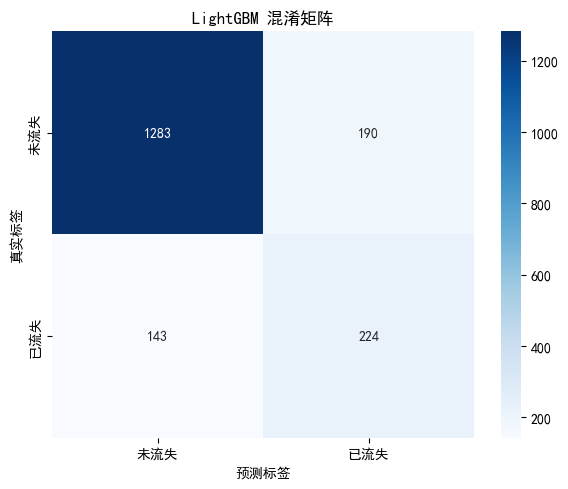

In [6]:
# ===================== 4. 可视化：混淆矩阵 + ROC曲线 =====================
# 4.1 绘制混淆矩阵（以LightGBM为例，精度最优）
plt.figure(figsize=(6, 5))
best_cm = results["LightGBM"]["confusion_matrix"]
sns.heatmap(best_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["未流失", "已流失"], yticklabels=["未流失", "已流失"])
plt.title("LightGBM 混淆矩阵")
plt.xlabel("预测标签")
plt.ylabel("真实标签")
plt.tight_layout()
plt.savefig(r"C:\Users\Administrator\Desktop\lgb_混淆矩阵.png", dpi=300)
plt.show()

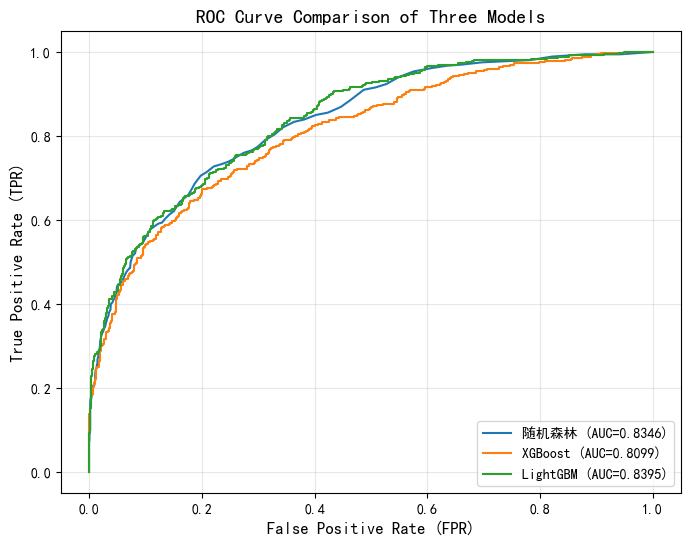

In [9]:
# 4.2 绘制多模型ROC曲线
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_pred_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.4f})")

plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)
plt.title("ROC Curve Comparison of Three Models", fontsize=14)
plt.legend(loc="lower right")  # 显示图例
plt.grid(alpha=0.3)
plt.savefig(r"C:\Users\Administrator\Desktop\ROC Curve Comparison of Three Models.png", dpi=300)

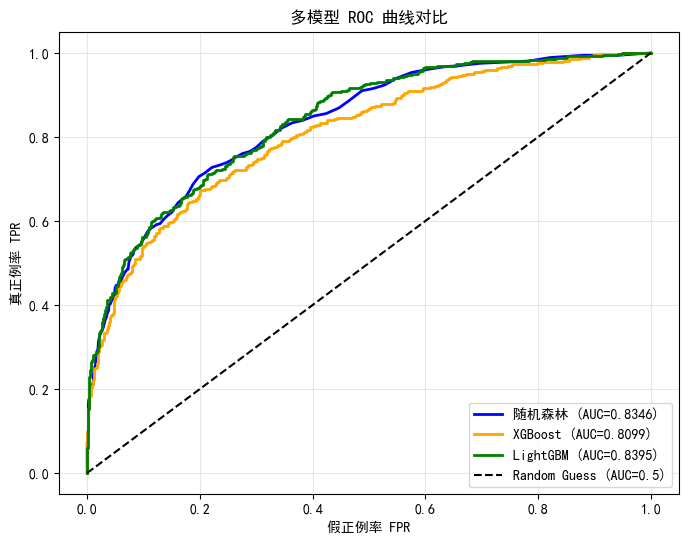

In [12]:
plt.figure(figsize=(8, 6))

# 画模型曲线
colors = ["blue", "orange", "green"]
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res["y_pred_proba"])
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f"{name} (AUC={res['auc']:.4f})")

# 画基准线
plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Guess (AUC=0.5)")

# 加上标题、坐标轴、图例
plt.xlabel("假正例率 FPR")
plt.ylabel("真正例率 TPR")
plt.title("多模型 ROC 曲线对比")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# 保存图片
plt.savefig(r"C:\Users\Administrator\Desktop\多模型ROC对比.png", dpi=300)
plt.show()